In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.seterr(all='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
url = "https://raw.githubusercontent.com/ananyatiw15/Hearing-Test-Classification/main/hearing_test.csv"
df = pd.read_csv(url)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [4]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


## EDA and Visualisation

In [5]:
df['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

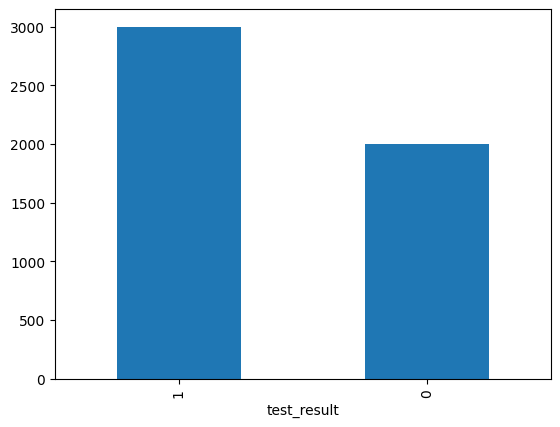

In [6]:
df['test_result'].value_counts().plot(kind='bar');

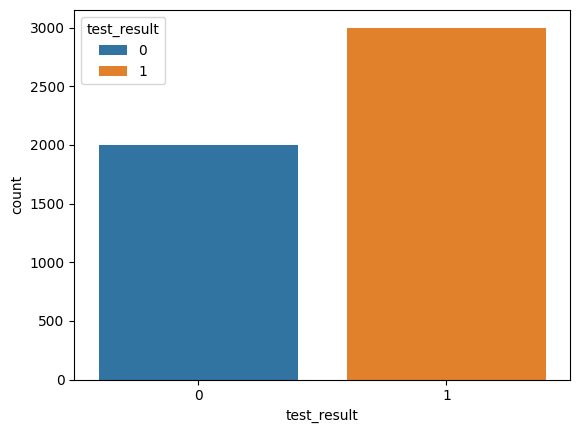

In [7]:
sns.countplot(data =df, x='test_result', hue='test_result');

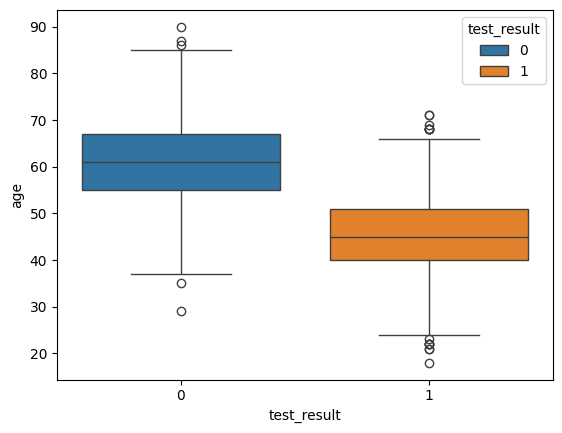

In [8]:
sns.boxplot(x='test_result', y = 'age', data =df,hue='test_result');

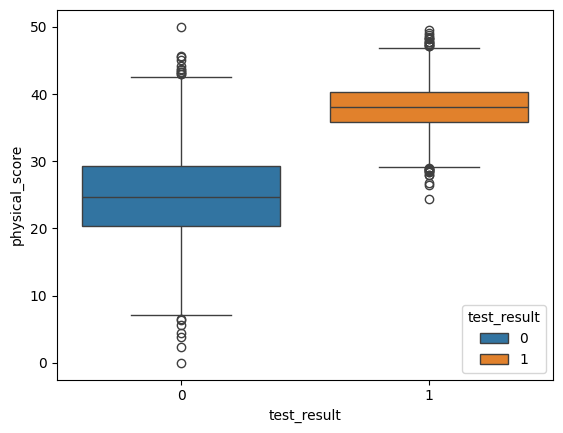

In [9]:
sns.boxplot(x='test_result', y = 'physical_score', data =df,hue='test_result');

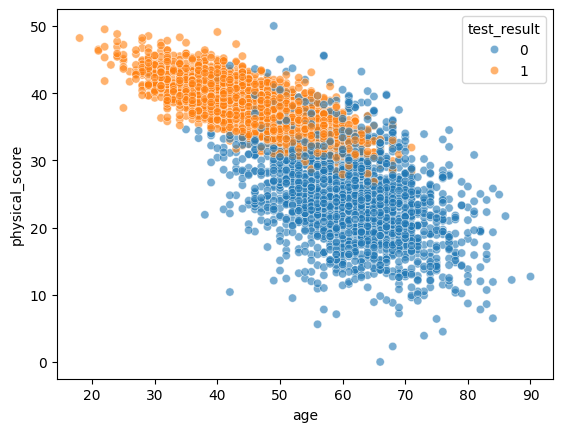

In [10]:
sns.scatterplot(data=df,x= 'age', y='physical_score', hue ='test_result',
               alpha=0.6);

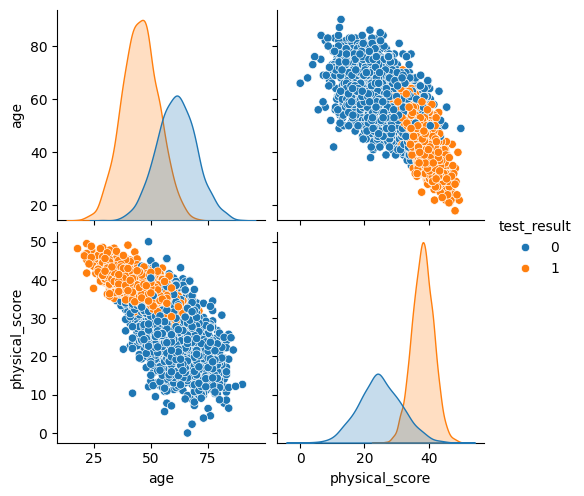

In [11]:
sns.pairplot(data =df, hue='test_result');

## Features(X) and Labels (y)

In [12]:
df.head(1)

,age,physical_score,test_result
0,33.0,40.7,1


In [13]:
X = df.drop('test_result', axis =1)
y = df['test_result']

In [14]:
print(X.shape)
print(y.shape)

(5000, 2)
(5000,)


## Train test split 

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.1,
                                                    random_state=101)

## Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)


## Logistic Regression Classifier

In [17]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(scaled_X_train, y_train)
y_pred =log_model.predict(scaled_X_test)

In [18]:
log_model.coef_

array([[-0.95017725,  3.46148946]])

In [19]:
y_pred[:5]

array([1, 1, 0, 1, 0])

In [20]:
# Check probability prediction
y_pred_proba =log_model.predict_proba(scaled_X_test)
y_pred_proba[:5]

array([[0.02380517, 0.97619483],
       [0.02688541, 0.97311459],
       [0.98922003, 0.01077997],
       [0.00190239, 0.99809761],
       [0.97506574, 0.02493426]])

## Model Evaluation

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
accuracy_score(y_test,y_pred)

0.93

In [23]:
confusion_matrix(y_test,y_pred)

array([[172,  21],
       [ 14, 293]])

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

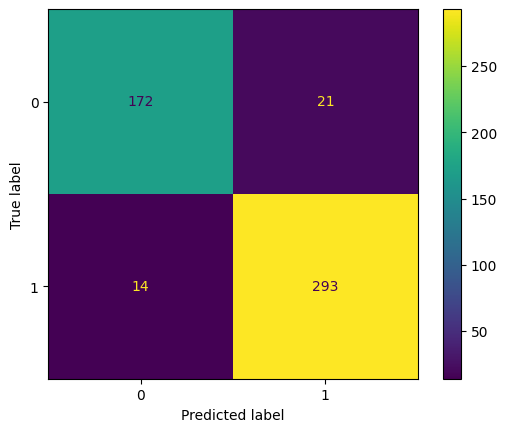

In [25]:
ConfusionMatrixDisplay.from_estimator(log_model,scaled_X_test,y_test)

scikit learn confusion matrix (is flipped)
```
    Predicted
                 Class 0  Class 1
Actual Class 0    TN       FP
       Class 1    FN       TP

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



In [27]:
from sklearn.metrics import precision_score, recall_score

In [28]:
precision_score(y_test, y_pred)

0.9331210191082803

In [29]:
recall_score(y_test, y_pred)

0.9543973941368078

In [30]:
from sklearn.metrics import RocCurveDisplay,PrecisionRecallDisplay

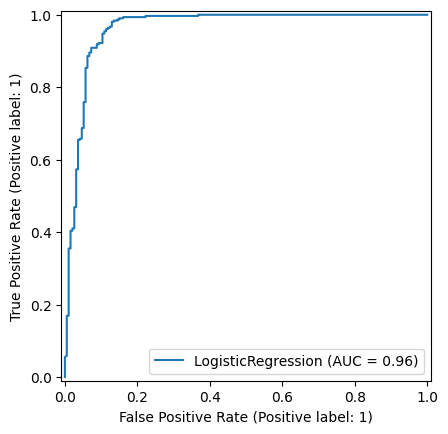

In [31]:
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test)

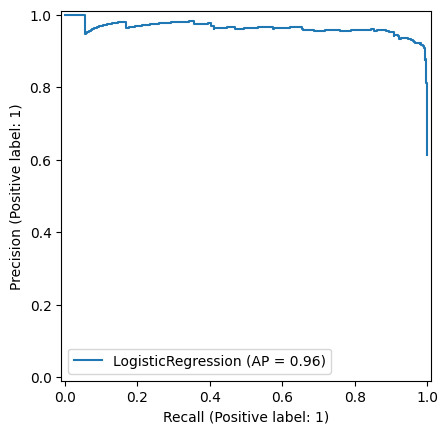

In [32]:
PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test)